<a href="https://colab.research.google.com/github/majaVtech/business-sales-analysis/blob/main/Notebooks/northstar_retail_sales_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Northstar Retail - Sales Analysis 2025**

## **1. Business Objective**

#### Objective

The objective of this analysis is to evaluate Northstar Retail's 2025 sales performance, identify data quality issues, calculate key business KPIs, analyze sales patterns, and provide actionable business recommendations.

#### **Business Questions**

The analysis aims to answer the following questions:

1. How reliable is the available sales data?
2. How much revenue did Northstar Retail generate in 2025?
3. How did revenue and sales volume change throughout the year?
4. Which product categories generate the most revenue?
5. Which products generate the most revenue and sales volume?
6. Which customers contribute the most revenue?
7. How does sales performance vary by city?
8. How do payment methods relate to sales performance?
9. How are discounts associated with revenue and average order value?
10. What actions could improve future business performance?

## **2. Import Libraries**

The analysis uses **Pandas** for data manipulation, and **Matplotlib** for data visualization.

Additional formatting tools are used to maintain a consistent and professional appearance across all charts. Custom helper functions are also defined for formatting large numerical values and axis labels, making business metrics easier to read.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# Professional chart style
plt.rcParams.update({
    "figure.figsize": (10, 6),
    "axes.titlesize": 15,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.2
})

MAIN_COLOR = "#1F4E79"
ACCENT_COLOR = "#5B9BD5"

def format_value(value):
    if value >= 1_000_000:
        return f"{value / 1_000_000:.2f}M KM"
    elif value >= 1_000:
        return f"{value / 1_000:.2f}K KM"
    else:
        return f"{value:.0f} KM"

def axis_formatter(x, pos):
    if x >= 1_000_000:
        return f"{x / 1_000_000:.1f}M"
    elif x >= 1_000:
        return f"{x / 1_000:.0f}K"
    else:
        return f"{x:.0f}"

## **3. Load Raw Data**

In [2]:
# Load raw sales data from GitHub
url = "https://raw.githubusercontent.com/majaVtech/business-sales-analysis/main/Data/raw_sales_data.csv"

df = pd.read_csv(url)

df.head()

,order_id,order_date,customer_id,customer_name,product,category,quantity,unit_price,discount,city,payment_method
0,ORD17439,2025-01-01,CUST0044,Customer 0044,Coffee Maker,Home & Kitchen,3,93.21,0.00,Sarajevo,PayPal
1,ORD11153,2025-01-01,CUST0256,Customer 0256,Skincare Set,Beauty,5,40.14,0.15,Doboj,Cash on Delivery
2,ORD05185,2025-01-01,CUST0392,Customer 0392,Printer,Office Supplies,2,142.94,0.00,Mostar,Cash on Delivery
3,ORD00849,2025-01-01,CUST0369,Customer 0369,Coffee Maker,Home & Kitchen,4,92.24,0.00,Mostar,Cash on Delivery
4,ORD07394,2025-01-01,CUST0269,Customer 0269,Running Shoes,Sports,3,86.09,0.15,Banja Luka,Credit Card


#### Dataset Overview

In [3]:
print("Shape:", df.shape)
print("-"*50)

df.info()
print("-"*50)

df.describe(include="all")

print("-"*50)
print("Columns:")
print(df.columns.tolist())

Shape: (20050, 11)
--------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20050 entries, 0 to 20049
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   order_id        20050 non-null  object 
 1   order_date      20050 non-null  object 
 2   customer_id     20050 non-null  object 
 3   customer_name   20050 non-null  object 
 4   product         20050 non-null  object 
 5   category        20050 non-null  object 
 6   quantity        20050 non-null  int64  
 7   unit_price      20050 non-null  float64
 8   discount        20050 non-null  float64
 9   city            19950 non-null  object 
 10  payment_method  19974 non-null  object 
dtypes: float64(2), int64(1), object(8)
memory usage: 1.7+ MB
--------------------------------------------------
--------------------------------------------------
Columns:
['order_id', 'order_date', 'customer_id', 'customer_name', 'pro

## **4. Data Quality Assessment**

### **4.1 Missing Values**

In [4]:
df.isna().sum()

,0
order_id,0
order_date,0
customer_id,0
customer_name,0
product,0
category,0
quantity,0
unit_price,0
discount,0
city,100


### **4.2 Duplicate Records**

In [5]:
print("Duplicated rows in dataset:", df.duplicated().sum())

Duplicated rows in dataset: 50


### **4.3 Categorical Value Consistency**

In [6]:
df['category'].value_counts(dropna=False)

,count
category,
Electronics,7291
Home & Kitchen,3621
Furniture,3048
Office Supplies,2204
Sports,2194
Beauty,1592
ELECTRONICS,32
FURNITURE,20
HOME & KITCHEN,17


### **4.4 Numerical Value Consistency**

In [7]:
print("Negative quantities:", (df['quantity'] < 0).sum())
print("Negative prices:", (df['unit_price'] < 0).sum())
print("Negative discounts:", (df['discount'] < 0).sum())

Negative quantities: 10
Negative prices: 5
Negative discounts: 0


### **4.5 Data Quality Summary**

The initial data quality assessment identified several issues that required attention before performing the sales analysis:

- Duplicate records were present in the dataset.
- Missing values were found in the `city` and `payment_method` columns.
- Category names contained inconsistent capitalization.
- Negative values were found in the `quantity` and `unit_price` columns.
- No negative values were found in the `discount` column.

These issues were addressed during the data cleaning stage to ensure that the subsequent business analysis was based on consistent and valid data.

## **5. Data Cleaning**

A separate copy of the dataset is created so that the original raw data remains unchanged throughout the analysis.

In [8]:
df_clean = df.copy()

### **5.1 Remove Complete Duplicates**

Complete duplicate records are removed to prevent the same transaction from being counted more than once.

In [9]:
df_clean = df_clean.drop_duplicates()

### **5.2 Remove Invalid Transactions**

Transactions with negative quantities or negative unit prices are considered invalid and are removed from the dataset.

In [10]:
df_clean = df_clean[
    (df_clean['quantity'] >= 0) &
    (df_clean['unit_price'] >= 0)
].copy()

### **5.3 Standardize Categories**

Category names are standardized to ensure consistent grouping and analysis.

In [11]:
df_clean['category'] = (
    df['category']
    .str.strip()
    .str.title()
)

### **5.4 Convert Order Date**

The `order_date` column is converted to datetime format to enable time-based analysis.

In [12]:
df_clean['order_date'] = pd.to_datetime(
    df_clean['order_date'],
    errors='coerce'
)

### **5.5 Validate Cleaning**

The cleaned dataset is checked to confirm that invalid numerical values were removed and that the data structure remains consistent.

In [13]:
print("Shape after cleaning:", df_clean.shape)
print("\nNegatve quantities:", (df_clean['quantity'] < 0).sum())
print("\nMissing values:")
print(df_clean.isna().sum())

Shape after cleaning: (19985, 11)

Negatve quantities: 0

Missing values:
order_id            0
order_date          0
customer_id         0
customer_name       0
product             0
category            0
quantity            0
unit_price          0
discount            0
city              100
payment_method     75
dtype: int64


> **Note:** Missing values in `city` and `payment_method` were retained because the transactions themselves remain valid. Imputing these categorical values could introduce unsupported assumptions, while removing the affected transactions would result in unnecessary data loss.

## **6. Feature Engineering**

Feature engineering is used to create additional variables required for the business analysis, including revenue and time-based variables.

### **6.1 Calculate Revenue**

Revenue is calculated for each transaction using quantity, unit price, and discount.

In [14]:
df_clean['revenue'] = (
    df_clean['quantity']
    * df_clean['unit_price']
    * (1 - df_clean['discount'])
)

### **6.2 Create Month Variables**

Month number and month name are extracted from the order date to support time-based sales analysis.

In [15]:
df_clean['month'] = df_clean['order_date'].dt.month

df_clean['month_name'] = df_clean['order_date'].dt.month_name()

## **7. Key Business KPIs**

The following KPIs provide a high-level overview of Northstar Retail's sales performance in 2025.


In [16]:
total_revenue = df_clean["revenue"].sum()
total_orders = df_clean["order_id"].nunique()
units_sold = df_clean["quantity"].sum()

average_order_value = total_revenue / total_orders
average_revenue_per_unit = total_revenue / units_sold

print(f"Total Revenue: {total_revenue:,.2f} KM")
print(f"Total Orders: {total_orders:,}")
print(f"Units Sold: {units_sold:,}")
print(f"Average Order Value: {average_order_value:,.2f} KM")
print(f"Average Revenue per Unit: {average_revenue_per_unit:,.2f} KM")

Total Revenue: 3,029,371.64 KM
Total Orders: 19,985
Units Sold: 35,064
Average Order Value: 151.58 KM
Average Revenue per Unit: 86.40 KM


## **8. Monthly Sales Analysis**

Monthly revenue, order volume, and units sold are analyzed to identify changes in sales performance throughout 2025.

In [17]:
monthly_sales = (
    df_clean
    .groupby('month_name')
    .agg(
        revenue=('revenue', 'sum'),
        orders=('order_id', 'nunique'),
        units_sold=('quantity', 'sum')
    )
    .reset_index()
)

Create month name in chronological ordering

In [18]:
month_order = [ "January", "February", "March", "April", "May", "June", "July", "August", "September", "October", "November", "December" ]
monthly_sales['month_name'] = (
    pd.Categorical(
        df_clean.groupby('month')['month_name'].first().values,
        categories=month_order,
        ordered=True
    )
)

monthly_sales

,month_name,revenue,orders,units_sold
0,January,256013.9680,1656,2872
1,February,272666.2900,1694,2997
2,March,260598.4205,1673,2884
3,April,234553.2895,1509,2723
4,May,268821.9100,1738,3084
5,June,236614.7690,1656,2903
6,July,243655.5245,1646,2894
7,August,247065.1645,1713,2966
8,September,258112.1755,1674,2894
9,October,254620.9550,1670,2958


### Monthly Revenue

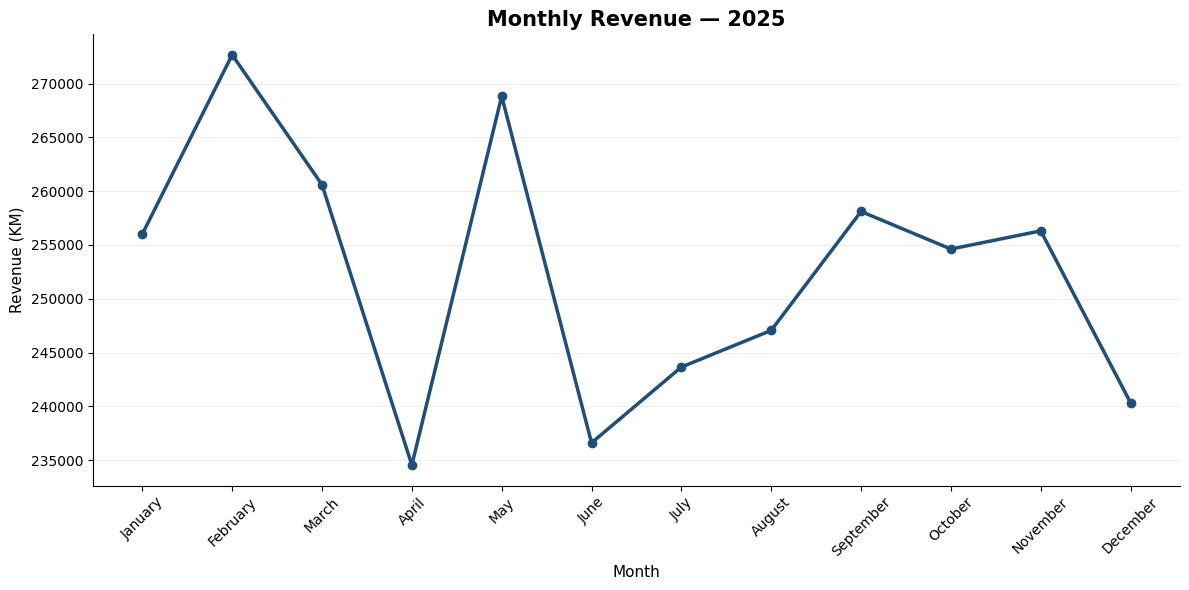

In [19]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_sales['month_name'],
    monthly_sales['revenue'],
    marker= 'o',
    linewidth=2.5,
    color=MAIN_COLOR
)

plt.title("Monthly Revenue — 2025")
plt.xlabel("Month")
plt.ylabel("Revenue (KM)")

plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.2)
plt.grid(axis="x", visible=False)

plt.tight_layout()
plt.show()

### **Key Finding**

- **Highest monthly revenue:** August — 272,666 KM
- **Lowest monthly revenue:** February — 234,553 KM

Revenue remained relatively stable throughout the year, with monthly revenue ranging from approximately 234.6K KM to 272.7K KM.

## **9. Revenue by Category**

Revenue is analyzed across product categories to identify the main contributors to total sales.

In [20]:
revenue_by_category = (
    df_clean
    .groupby('category')
    .agg(
        revenue=('revenue', 'sum'),
        orders=('order_id', 'nunique'),
        units_sold=('quantity', 'sum')
    )
    .reset_index()
    .sort_values('revenue', ascending=False)
)
revenue_by_category['revenue'] = revenue_by_category['revenue'].round(2)

revenue_by_category

,category,revenue,orders,units_sold
1,Electronics,1212669.42,7300,12890
2,Furniture,619382.34,3056,5339
3,Home & Kitchen,618000.22,3628,6303
5,Sports,226123.12,2198,3835
4,Office Supplies,213973.97,2211,3849
0,Beauty,139222.57,1592,2848


#### Revenue Share

In [21]:
revenue_by_category['revenue_share'] = (
    revenue_by_category['revenue']
    / total_revenue * 100
).round(2)

revenue_by_category

,category,revenue,orders,units_sold,revenue_share
1,Electronics,1212669.42,7300,12890,40.03
2,Furniture,619382.34,3056,5339,20.45
3,Home & Kitchen,618000.22,3628,6303,20.40
5,Sports,226123.12,2198,3835,7.46
4,Office Supplies,213973.97,2211,3849,7.06
0,Beauty,139222.57,1592,2848,4.60


#### Visualization

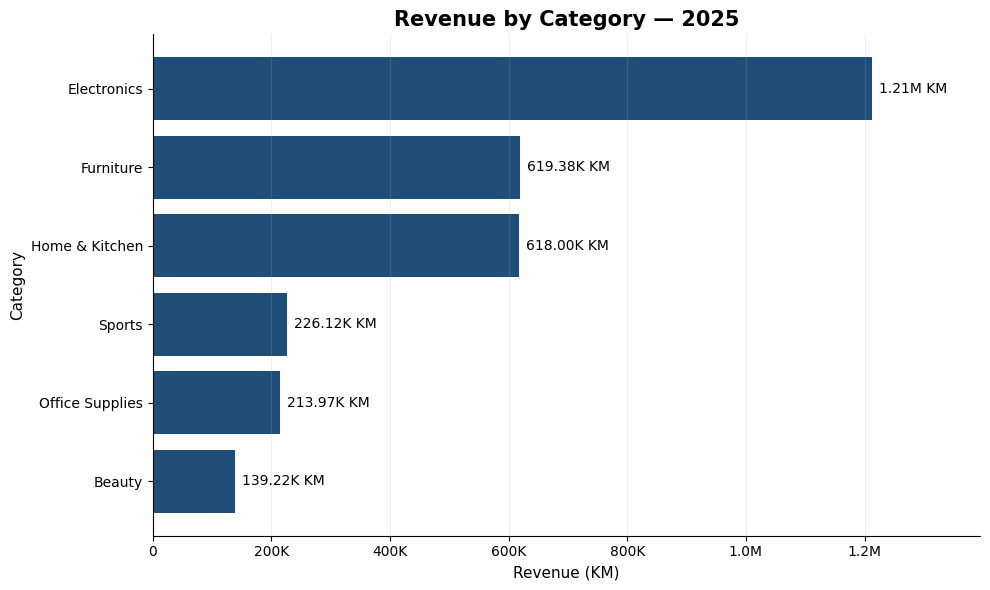

In [22]:
plt.figure(figsize=(10, 6))

bars = plt.barh(
    revenue_by_category["category"],
    revenue_by_category["revenue"],
    color=MAIN_COLOR
)

plt.title("Revenue by Category — 2025")
plt.xlabel("Revenue (KM)")
plt.ylabel("Category")

plt.gca().invert_yaxis()

plt.xlim(0, revenue_by_category["revenue"].max() * 1.15)

ax = plt.gca()

# Format X axis
ax.xaxis.set_major_formatter(FuncFormatter(axis_formatter))

# Data labels
ax.bar_label(
    bars,
    labels=[
        format_value(value)
        for value in revenue_by_category["revenue"]
    ],
    padding=5
)

plt.grid(axis="x", alpha=0.2)
plt.grid(axis="y", visible=False)

plt.tight_layout()
plt.show()

### **Key Finding**

Electronics generated approximately **1.21 million KM**, making it the largest revenue-generating category in 2025.

## **10. Product Analysis**

Product performance is analyzed using both revenue and sales volume. This helps distinguish high-value products from high-volume products.

### **10.1 Top Products by Revenue**

In [23]:
revenue_by_product = (
    df_clean
    .groupby('product')
    .agg(
        revenue=('revenue', 'sum'),
        orders=('order_id', 'nunique'),
        units_sold=('quantity', 'sum')
    )
    .reset_index()
    .sort_values('revenue', ascending=False)
)

top_products_revenue = revenue_by_product.head(10)

top_products_revenue

,product,revenue,orders,units_sold
11,Smartphone,664732.3665,804,1401
7,Office Chair,497534.8040,1585,2768
0,Air Fryer,319511.9835,1622,2802
2,Coffee Maker,298488.2410,2006,3501
5,Mechanical Keyboard,263216.4335,1955,3469
8,Printer,200155.6045,807,1413
9,Running Shoes,176345.9695,1192,2073
1,Bluetooth Speaker,162232.2420,1573,2851
12,Wireless Mouse,122488.3735,2968,5169
3,Desk Lamp,121847.5350,1471,2571


#### Visualization

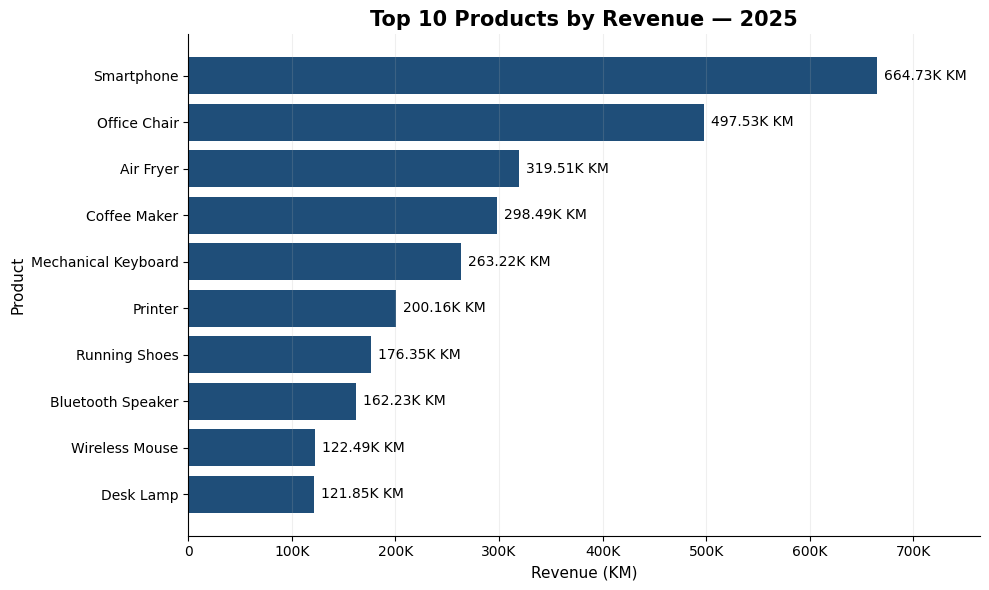

In [24]:
plt.figure(figsize=(10, 6))

bars = plt.barh(
    top_products_revenue["product"],
    top_products_revenue["revenue"],
    color=MAIN_COLOR
)

plt.title("Top 10 Products by Revenue — 2025")
plt.xlabel("Revenue (KM)")
plt.ylabel("Product")

plt.gca().invert_yaxis()

plt.xlim(0, top_products_revenue["revenue"].max() * 1.15)

ax = plt.gca()

# Format X axis
ax.xaxis.set_major_formatter(FuncFormatter(axis_formatter))

# Data labels
ax.bar_label(
    bars,
    labels=[
        format_value(value)
        for value in top_products_revenue["revenue"]
    ],
    padding=5
)

plt.grid(axis="x", alpha=0.2)
plt.grid(axis="y", visible=False)

plt.tight_layout()
plt.show()

### **10.2 Top Products by Units Sold**

In [25]:
top_products_units = (
    df_clean
    .groupby("product")
    .agg(
        units_sold=("quantity", "sum"),
        orders=("order_id", "nunique"),
        revenue=("revenue", "sum")
    )
    .reset_index()
    .sort_values("units_sold", ascending=False)
    .head(10)
)

top_products_units

,product,units_sold,orders,revenue
12,Wireless Mouse,5169,2968,122488.3735
2,Coffee Maker,3501,2006,298488.2410
5,Mechanical Keyboard,3469,1955,263216.4335
1,Bluetooth Speaker,2851,1573,162232.2420
0,Air Fryer,2802,1622,319511.9835
7,Office Chair,2768,1585,497534.8040
3,Desk Lamp,2571,1471,121847.5350
6,Notebook,2436,1404,13818.3685
9,Running Shoes,2073,1192,176345.9695
13,Yoga Mat,1762,1006,49777.1555


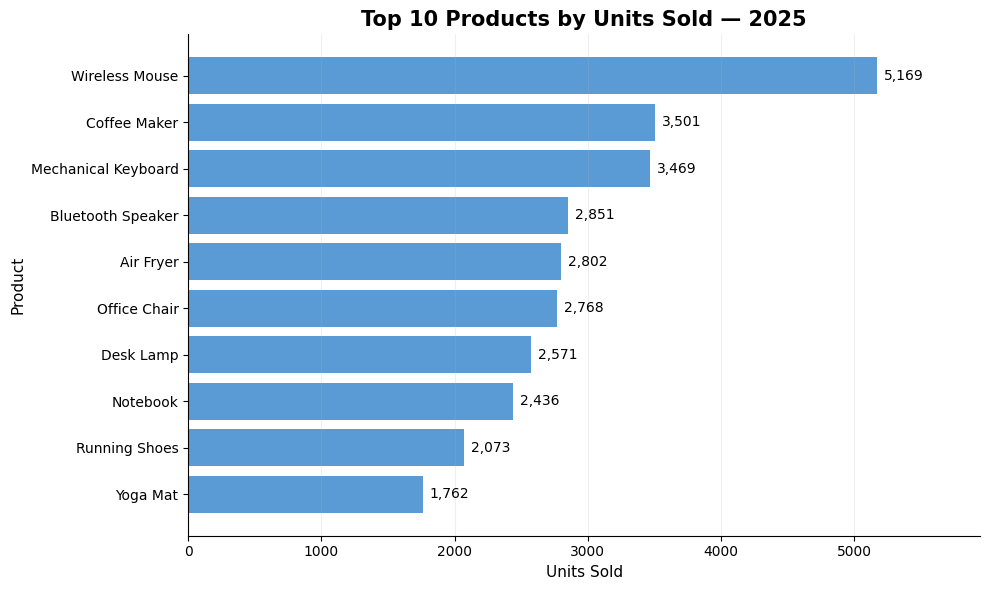

In [26]:
plt.figure(figsize=(10, 6))

bars = plt.barh(
    top_products_units["product"],
    top_products_units["units_sold"],
    color=ACCENT_COLOR
)

plt.title("Top 10 Products by Units Sold — 2025")
plt.xlabel("Units Sold")
plt.ylabel("Product")

plt.gca().invert_yaxis()

plt.xlim(0, top_products_units["units_sold"].max() * 1.15)

ax = plt.gca()

ax.bar_label(
    bars,
    labels=[
        f"{value:,.0f}"
        for value in top_products_units["units_sold"]
    ],
    padding=5
)

plt.grid(axis="x", alpha=0.2)
plt.grid(axis="y", visible=False)

plt.tight_layout()
plt.show()

### **Key Finding**

The **Smartphone** generated the highest revenue, while the **Wireless Mouse** had the highest sales volume.

This demonstrates why both revenue and units sold should be considered when evaluating product performance.

## **11. Customer Analysis**

Customer performance is analyzed based on revenue contribution and average order value.

### **11.1 Top Customers by Revenue**

In [27]:
customer_analysis = (
    df_clean
    .groupby(['customer_id', 'customer_name'])
    .agg(
        revenue=('revenue', 'sum'),
        orders=('order_id', 'nunique'),
        units_sold=('quantity', 'sum')
    )
    .reset_index()
    .sort_values('revenue', ascending=False)
)

top_customers_revenue = customer_analysis.head(10)
top_customers_revenue

,customer_id,customer_name,revenue,orders,units_sold
386,CUST0387,Customer 0387,12503.6120,47,95
100,CUST0101,Customer 0101,12360.5245,48,108
36,CUST0037,Customer 0037,10966.5900,41,73
83,CUST0084,Customer 0084,10719.8765,51,95
399,CUST0400,Customer 0400,10371.1940,55,104
327,CUST0328,Customer 0328,10183.8335,40,67
404,CUST0405,Customer 0405,9988.6590,55,108
130,CUST0131,Customer 0131,9866.1865,48,80
254,CUST0255,Customer 0255,9855.0805,51,97
87,CUST0088,Customer 0088,9733.3400,48,88


#### Visualization

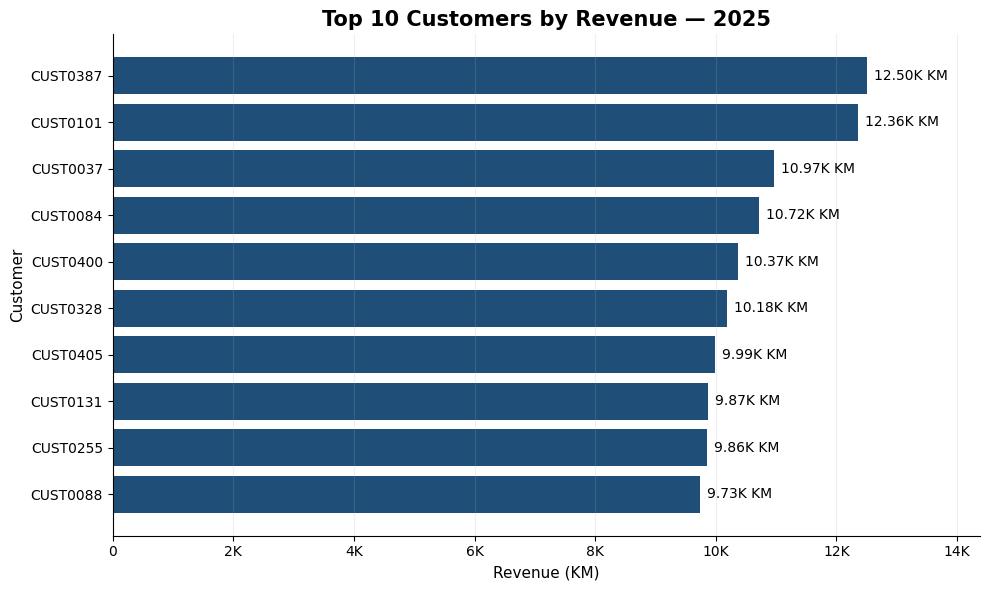

In [28]:
plt.figure(figsize=(10, 6))

bars = plt.barh(
    top_customers_revenue["customer_id"],
    top_customers_revenue["revenue"],
    color=MAIN_COLOR
)

plt.title("Top 10 Customers by Revenue — 2025")
plt.xlabel("Revenue (KM)")
plt.ylabel("Customer")

plt.gca().invert_yaxis()

plt.xlim(0, top_customers_revenue["revenue"].max() * 1.15)

ax = plt.gca()

# Format X axis
ax.xaxis.set_major_formatter(FuncFormatter(axis_formatter))

# Data labels
ax.bar_label(
    bars,
    labels=[
        format_value(value)
        for value in top_customers_revenue["revenue"]
    ],
    padding=5
)

plt.grid(axis="x", alpha=0.2)
plt.grid(axis="y", visible=False)

plt.tight_layout()
plt.show()

### **11.2 Customer Average Order Value**

Average order value is calculated to identify customers with higher-value individual orders.

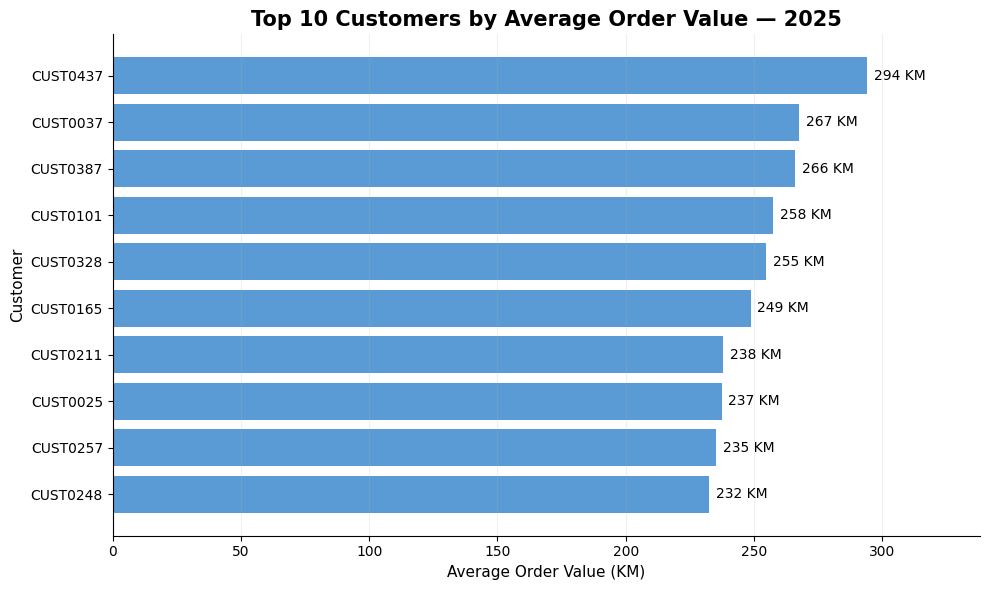

In [29]:
customer_analysis['avg_order_value'] = (
    customer_analysis['revenue']
    / customer_analysis['orders']
)

top_customers_aov = (
    customer_analysis
    .sort_values('avg_order_value', ascending=False)
    .head(10)
)
top_customers_aov

plt.figure(figsize=(10, 6))

bars = plt.barh(
    top_customers_aov["customer_id"],
    top_customers_aov["avg_order_value"],
    color=ACCENT_COLOR
)

plt.title("Top 10 Customers by Average Order Value — 2025")
plt.xlabel("Average Order Value (KM)")
plt.ylabel("Customer")

plt.gca().invert_yaxis()

plt.xlim(0, top_customers_aov["avg_order_value"].max() * 1.15)

ax = plt.gca()

ax.bar_label(
    bars,
    labels=[
        format_value(value)
        for value in top_customers_aov["avg_order_value"]
    ],
    padding=5
)

plt.grid(axis="x", alpha=0.2)
plt.grid(axis="y", visible=False)

plt.tight_layout()
plt.show()


## **12. Sales by City**

Sales performance is analyzed by city to identify geographic differences in revenue and order volume.

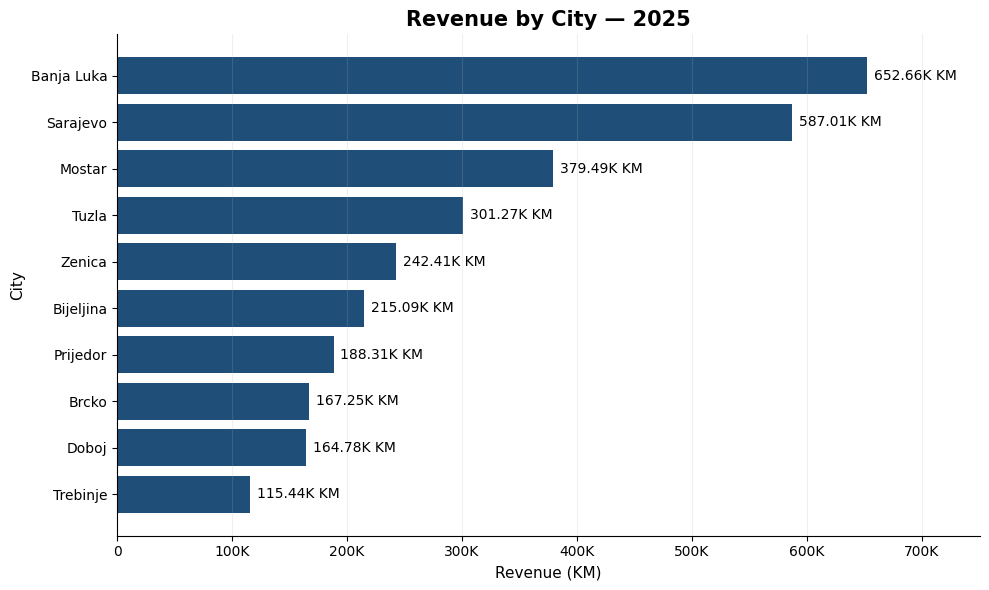

In [30]:
revenue_by_city = (
    df_clean
    .groupby('city')
    .agg(
        revenue=('revenue', 'sum'),
        orders=('order_id', 'nunique'),
        units_sold=('quantity', 'sum')
    )
    .reset_index()
    .sort_values('revenue', ascending=False)
)

revenue_by_city

# Visualization

plt.figure(figsize=(10, 6))

bars = plt.barh(
    revenue_by_city["city"],
    revenue_by_city["revenue"],
    color=MAIN_COLOR
)

plt.title("Revenue by City — 2025")
plt.xlabel("Revenue (KM)")
plt.ylabel("City")

plt.gca().invert_yaxis()

plt.xlim(0, revenue_by_city["revenue"].max() * 1.15)

ax = plt.gca()

# Format X axis
ax.xaxis.set_major_formatter(FuncFormatter(axis_formatter))

# Data labels
ax.bar_label(
    bars,
    labels=[
        format_value(value)
        for value in revenue_by_city["revenue"]
    ],
    padding=5
)

plt.grid(axis="x", alpha=0.2)
plt.grid(axis="y", visible=False)

plt.tight_layout()
plt.show()


### **12.1 Average Order Value by City**

In [31]:
revenue_by_city['avg_order_value'] = (
    revenue_by_city['revenue']
    / revenue_by_city['orders']
)

city_aov = revenue_by_city.sort_values(
    'avg_order_value',
    ascending=False
)

city_aov

,city,revenue,orders,units_sold,avg_order_value
3,Doboj,164776.2520,1057,1845,155.890494
4,Mostar,379490.0750,2440,4294,155.528719
9,Zenica,242411.6735,1559,2701,155.491773
1,Bijeljina,215088.6745,1392,2412,154.517726
5,Prijedor,188307.9285,1220,2163,154.350761
6,Sarajevo,587007.5920,3823,6877,153.546323
7,Trebinje,115436.0700,752,1327,153.505412
8,Tuzla,301274.9745,2008,3528,150.037338
0,Banja Luka,652657.7715,4466,7709,146.139223
2,Brcko,167253.0830,1168,2039,143.196133


### **Key Finding**

Banja Luka generated the highest total revenue, while Doboj had the highest average order value.

Banja Luka's higher total revenue is primarily associated with its larger number of orders rather than a higher average order value.

> **Note:** Transactions with missing city information were retained in the cleaned dataset but are excluded from city-level aggregation because their geographic information is unavailable.

## **13. Payment Method Analysis**

Payment methods are analyzed to compare their contribution to revenue, order volume, and average order value.

In [32]:
payment_analysis = (
    df_clean
    .groupby('payment_method')
    .agg(
        revenue=('revenue', 'sum'),
        orders=('order_id', 'nunique'),
        units_sold=('quantity', 'sum')
    )
    .reset_index()
)
payment_analysis['revenue'] = payment_analysis['revenue'].round(2)

payment_analysis

,payment_method,revenue,orders,units_sold
0,Bank Transfer,442324.30,3007,5231
1,Cash on Delivery,457880.75,3052,5370
2,Credit Card,1339945.89,8891,15609
3,PayPal,770796.67,4960,8712


### **13.1 Revenue by Payment Method**

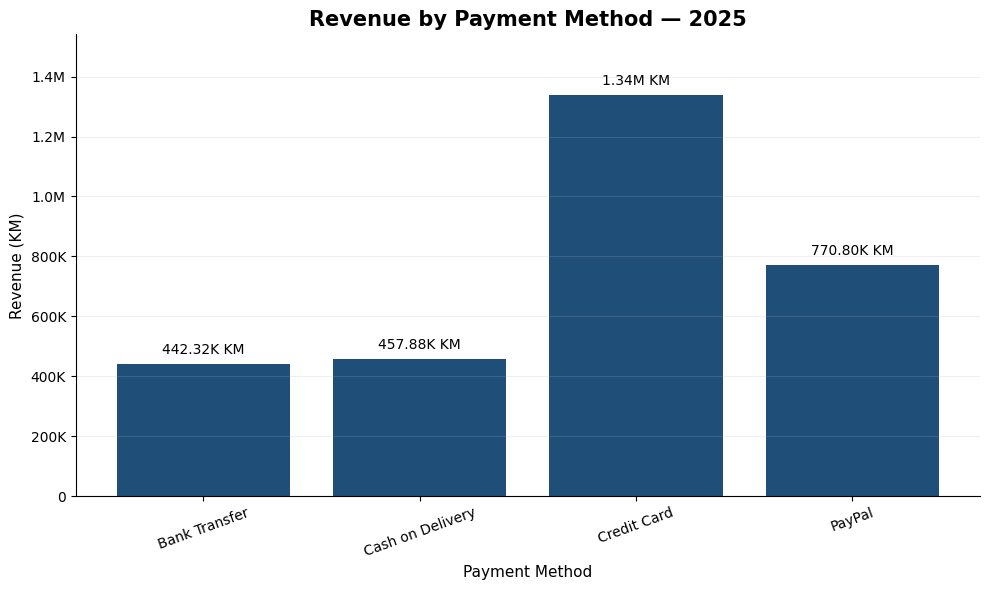

In [33]:
plt.figure(figsize=(10, 6))

bars = plt.bar(
    payment_analysis["payment_method"],
    payment_analysis["revenue"],
    color=MAIN_COLOR
)

plt.title("Revenue by Payment Method — 2025")
plt.xlabel("Payment Method")
plt.ylabel("Revenue (KM)")

plt.xticks(rotation=20)

plt.ylim(0, payment_analysis["revenue"].max() * 1.15)

ax = plt.gca()

# Format Y axis
ax.yaxis.set_major_formatter(FuncFormatter(axis_formatter))

# Data labels
ax.bar_label(
    bars,
    labels=[
        format_value(value)
        for value in payment_analysis["revenue"]
    ],
    padding=5
)

plt.grid(axis="y", alpha=0.2)
plt.grid(axis="x", visible=False)

plt.tight_layout()
plt.show()


### **13.2 Average Order Value**

In [34]:
payment_analysis["avg_order_value"] = (
    payment_analysis["revenue"]
    / payment_analysis["orders"]
)

payment_aov = payment_analysis.sort_values(
    'avg_order_value',
    ascending=False
)

payment_aov


,payment_method,revenue,orders,units_sold,avg_order_value
3,PayPal,770796.67,4960,8712,155.402554
2,Credit Card,1339945.89,8891,15609,150.708119
1,Cash on Delivery,457880.75,3052,5370,150.026458
0,Bank Transfer,442324.30,3007,5231,147.098204


### **Key Finding**

Credit Card generated the highest total revenue, while PayPal had the highest average order value.

The differences in average order value between payment methods were relatively small.

## **14. Discount Analysis**

Discount levels are analyzed to examine their relationship with revenue, order volume, and average order value.

In [35]:
discount_analysis = (
    df_clean
    .groupby('discount')
    .agg(
        revenue=('revenue', 'sum'),
        orders=('order_id', 'nunique'),
        units_sold=('quantity', 'sum')
    )
    .reset_index()
    .sort_values('discount')
)

discount_analysis['avg_order_value'] =(
    discount_analysis['revenue']
    / discount_analysis['orders']
)

discount_analysis['revenue_share'] = (
    discount_analysis['revenue']
    / total_revenue * 100
).round(2)
discount_analysis['discount_pct'] = (
    discount_analysis['discount'] * 100
)
discount_analysis['revenue'] = discount_analysis['revenue'].round(2)

discount_analysis

,discount,revenue,orders,units_sold,avg_order_value,revenue_share,discount_pct
0,0.00,1445619.34,8952,15611,161.485628,47.72,0.0
1,0.05,747758.02,5004,8833,149.432057,24.68,5.0
2,0.10,441330.02,3034,5328,145.461444,14.57,10.0
3,0.15,272607.16,2040,3611,133.630962,9.00,15.0
4,0.20,122057.10,955,1681,127.808486,4.03,20.0


### **14.1 Revenue by Discount**

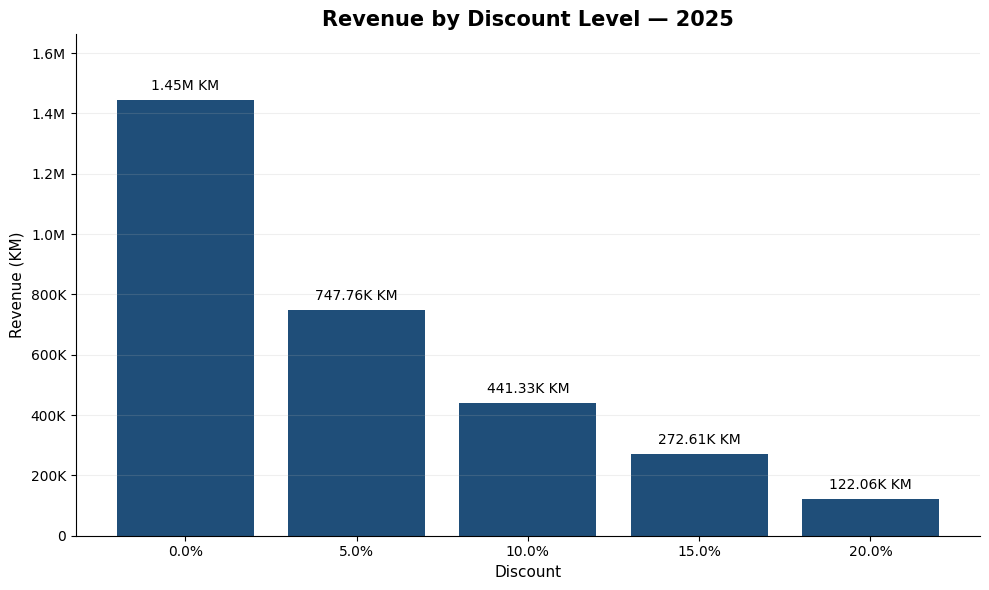

In [36]:
plt.figure(figsize=(10, 6))

bars = plt.bar(
    discount_analysis["discount_pct"].astype(str) + "%",
    discount_analysis["revenue"],
    color=MAIN_COLOR
)

plt.title("Revenue by Discount Level — 2025")
plt.xlabel("Discount")
plt.ylabel("Revenue (KM)")

plt.ylim(0, discount_analysis["revenue"].max() * 1.15)

ax = plt.gca()

# Format Y axis
ax.yaxis.set_major_formatter(FuncFormatter(axis_formatter))

# Data labels
ax.bar_label(
    bars,
    labels=[
        format_value(value)
        for value in discount_analysis["revenue"]
    ],
    padding=5
)

plt.grid(axis="y", alpha=0.2)
plt.grid(axis="x", visible=False)

plt.tight_layout()
plt.show()

### **14.2 Average Order Value by Discount**

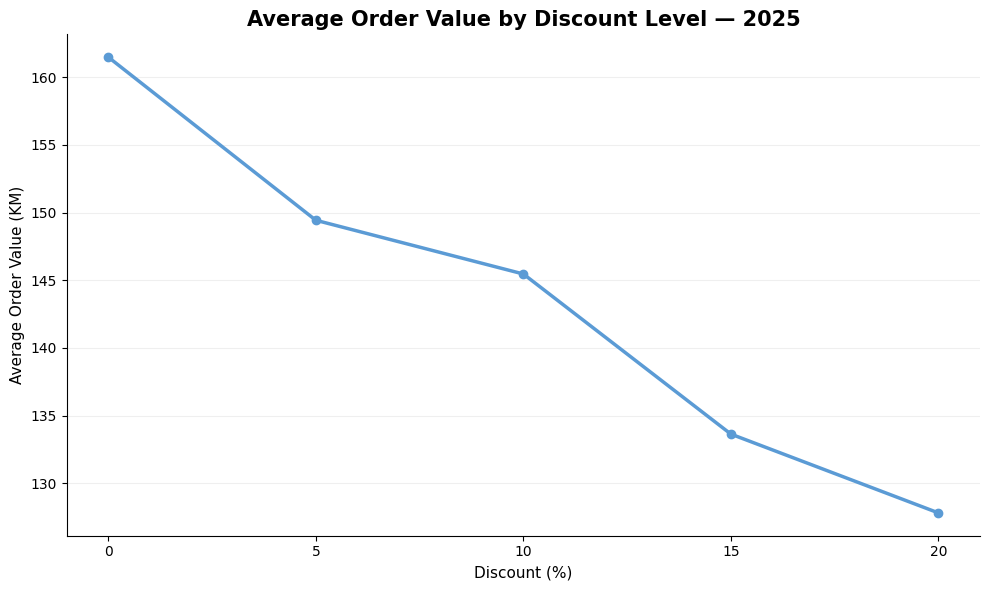

In [37]:
plt.figure(figsize=(10, 6))

plt.plot(
    discount_analysis["discount_pct"],
    discount_analysis["avg_order_value"],
    marker="o",
    linewidth=2.5,
    color=ACCENT_COLOR
)

plt.title("Average Order Value by Discount Level — 2025")
plt.xlabel("Discount (%)")
plt.ylabel("Average Order Value (KM)")

plt.xticks(discount_analysis["discount_pct"])

plt.grid(axis="y", alpha=0.2)
plt.grid(axis="x", visible=False)

plt.tight_layout()
plt.show()

### **Key Finding**

Orders without discounts generated approximately **47.7% of total revenue** and had an average order value of approximately **161 KM**.

At a 20% discount, the average order value was approximately **128 KM**.

The results show an association between higher discount levels and lower average order values. However, this analysis does not establish a causal relationship, as differences in product mix and other factors may also influence order value.

## **15. Business Insights & Recommendations**

### **Business Insights**

#### **1. Revenue remained relatively stable**

Northstar Retail generated approximately **3.03 million KM** in revenue from **19,985 orders**.

Monthly revenue remained relatively stable throughout 2025. **August** was the strongest month, generating approximately **272,666 KM**, while **February** was the weakest with approximately **234,553 KM**.

#### **2. Electronics is the leading category**

The **Electronics** category generated approximately **1.21 million KM**, making it the largest contributor to total revenue.

This indicates that Electronics represents an important revenue driver for the business and should be closely monitored in terms of inventory, product availability, and future sales performance.

#### **3. High revenue and high sales volume are different concepts**

The **Smartphone** generated the highest product revenue, while the **Wireless Mouse** recorded the highest number of units sold.

This demonstrates that product performance should be evaluated using multiple metrics, rather than relying on revenue or sales volume alone.

#### **4. Banja Luka has the highest total revenue**

**Banja Luka** generated approximately **653,000 KM**, the highest revenue among the analyzed cities.

However, its average order value was approximately **146 KM**, while **Doboj** had the highest average order value at approximately **156 KM**.

Banja Luka's strong revenue performance is therefore primarily associated with a higher number of orders rather than a significantly higher value per order.

#### **5. Higher discounts were associated with lower average order values**

Orders without discounts generated approximately **47.7% of total revenue** and had an average order value of approximately **161 KM**.

At a **20% discount**, the average order value was approximately **128 KM**.

The analysis shows an association between higher discount levels and lower average order values. However, this does not establish a causal relationship, as product mix, customer behavior, and other factors may also influence order value.

Discounting should therefore be evaluated together with sales volume, product category, and profitability.


## **16. Recommendations**

Based on the analysis, the following actions are recommended to support Northstar Retail's future sales performance.

#### **1. Prioritize High-Value Products**

Monitor inventory availability and sales performance for products that contribute substantially to total revenue, particularly key products such as the **Smartphone** and **Office Chair**.

#### **2. Distinguish High-Volume and High-Value Products**

Evaluate product performance using both **revenue** and **units sold**. High-volume products and high-revenue products may require different inventory, pricing, and promotional strategies.

#### **3. Increase Order Value in High-Volume Markets**

Explore **bundles, cross-selling, and complementary products** in cities with high order volumes, such as Banja Luka, to potentially increase average order value.

#### **4. Use Discounts Selectively**

Evaluate discount campaigns based on their impact on **sales volume, revenue, average order value, and profitability**. Larger discounts should be used when the additional sales generated justify the reduction in price.

#### **5. Monitor Monthly Performance**

Track **monthly revenue, orders, and units sold** on a regular basis to identify changes in sales performance and respond to weaker periods.

#### **6. Improve Data Quality**

Introduce regular data-quality checks for **duplicates, missing values, inconsistent category names, and invalid numerical values**. Consistent data-quality monitoring will improve the reliability of future business reports and analysis.


## **17. Measurable KPIs & Targets**

The following targets are proposed management objectives based on the **2025 baseline**. They are intended to provide measurable benchmarks for monitoring future business performance.

| **KPI**                      | **2025 Baseline** |           **Proposed Target** |
| ---------------------------- | ----------------: | ----------------------------: |
| **Total Revenue**            |          3.03M KM |                      **+10%** |
| **Total Orders**             |            19,985 |                   **21,000+** |
| **Average Order Value**      |         151.58 KM |                   **160+ KM** |
| **Units Sold**               |            35,064 |                   **37,000+** |
| **Electronics Revenue**      |          1.21M KM |                      **+10%** |
| **Discounted Revenue Share** |            52.28% |                      **≤50%** |
| **Monthly Revenue**          |  234.6K–272.7K KM |                  **≥250K KM** |
| **Data Quality Issues**      |          Multiple | **<1% critical-field issues** |

> **Note:** Proposed targets are management objectives for future performance and are not directly derived from the historical dataset.

### **KPI Monitoring**

The recommended management dashboard should monitor the following indicators:

* **Total Revenue**
* **Total Orders**
* **Average Order Value**
* **Units Sold**
* **Monthly Revenue**
* **Revenue by Category**
* **Top Products**
* **Revenue by City**
* **Discounted Revenue Share**
* **Data Quality Rate**

These KPIs should be reviewed **monthly** and compared with the proposed targets to identify changes in performance and support data-driven business decisions.



## **18. Final Conclusion**

Northstar Retail generated approximately **3.03 million KM in revenue across 19,985 orders during 2025**.

The analysis shows a relatively stable sales pattern throughout the year, with **Electronics** representing the largest revenue category and several high-value products contributing substantially to overall revenue.

The findings also demonstrate the importance of evaluating multiple business metrics. High sales volume does not necessarily correspond to high revenue, while strong total revenue in a city does not necessarily indicate a higher average order value.

The main areas for future management attention are **high-value product management, increasing average order value, selective use of discounts, and maintaining consistent data quality**.

The proposed KPI targets provide a measurable framework for monitoring progress and evaluating future business performance. Regular review of these indicators can help management identify changes in sales performance and make more informed, data-driven decisions.
